In [1]:
%load_ext autoreload
%autoreload 2

from copy import deepcopy

import numpy as np
from matplotlib import pyplot as plt

import ipywidgets as widgets
from ipywidgets import interact, interact_manual

import pandas as pd
import seaborn as sns

from paper_utils import wandb_restore

i2c = {i: f"\x1b[{a}" for i, a in enumerate([
    '1m', '31m', '33m', '34m', '35m', '36m', '37m', '38m'])}
r = "\x1b[0m"

* n_regenrate 1--5 is currently running at https://wandb.ai/jlko/hallu_long/table?workspace=user-jlko (to give us the ablation we want!)

In [2]:
# Initial runs.
runs = {
    # note this has the question extraction bug (no numbering), so results are likely a bit pessimistic
    # (also has the major/minor replacement bug)
    'flexible': 'hallu_long/5yfel47n',
    # get a yes/no per regenerated question!
    'flexible_with_prob': 'hallu_long/n4vgl562',
    'entailment': 'hallu_long/gjkhe90u',
    # is with not_answerable and improved question generation prompt
    'entailment_v2': 'hallu_long/buo2yw8e',
    'deberta': 'hallu_long/3xyx3v89', 
    # deberta run where expected answer not used for clustering (comparison would be fairer if we had a new regen_answer)
    'deberta_no_expected': 'hallu_long/q8glz91c',
    # manually set uncertainty to maximum if 'not answerable', 'not provided', 'unclear', 'unknown' appears >= 2 times
    'deberta_not_answerable': 'hallu_long/dd13rmis',
    # is with not_answerable and improved question generation prompt
    'deberta_na_v2': 'hallu_long/d97uybct',
    'entailment_llm': 'hallu_long/eqlu6ldt',
    # ask for semantically equivalent instead of 'mean the same'
    'equivalent_llm': 'hallu_long/9egqfjs1',
    # ask closer to how we actually compute entailment: at least one entails the other!
    # (could even refine to include that they don't contradict each other?)
    '1way_entailment_llm': 'hallu_long/74yhw70v',
    'self_check': 'hallu_long/h0hl8glr',
    'ptrue': 'hallu_long/bgdgnaeq',
}

# 10/10/23 Final runs. Rerun across old questions and additional new questions.
runs = {
    **runs,
    'Fself_check': 'hallu_long/2madgs36',
    'Fptrue': 'hallu_long/runs/0j1oswba',
    'FptrueOrig': 'hallu_long/runs/6r8vh6on',  # prompt closer to original
    # this one failed on the last datapoint, restore and recompute
    # 'FQADebertaEntailment': 'hallu_long/3twf6uqm',
    'FQADebertaEntailment': 'hallu_long/3vvlav6n',
    'FQADebertaEntailment-A6': 'hallu_long/vhiovr2r',  # 6 regenerated answers!
    'FQAFlexibleEquivalence': 'hallu_long/p44zr574',
    'FQADebertaEntailment-A1': 'hallu_long/hz1tngeb',  # x regenerated answers!
    'FQADebertaEntailment-A2': 'hallu_long/0vvn2qpx',  # x regenerated answers!
    'FQADebertaEntailment-A4': 'hallu_long/ttclhrxb',  # x regenerated answers!
    'FQADebertaEntailment-A5': 'hallu_long/xxwbx8k5',  # x regenerated answers!
}


all_results, all_metrics = {}, {}
for name, url in runs.items():
    results, config = wandb_restore(url, 'results.pkl')
    print(i2c[0] + name + r)
    print(config)
    print(results['results']['restored_config'])

    all_results[name] = results
    all_metrics[name] = results['results']['metrics']

flexible
{'wait': False, 'debug': False, 'model': 'QAFlexibleEquivalence', 'num_data': 1e+19, 'n_questions': 'three', 'n_regenerate': 3, 'truth_target': 'facts', 'restore_stages': ['gen_qs', 'answer_qs', 'equivalence'], 'restore_from_wandb_id': 'hallu_long/euyz5itn', 'n_stochastic_questions': 2}
{'debug': False, 'model': 'QAFlexibleEquivalence', 'num_data': 1e+19, 'n_questions': 'three', 'n_regenerate': 3, 'truth_target': 'facts', 'restore_stages': [], 'restore_from_wandb_id': None, 'n_stochastic_questions': 2}
flexible_with_prob
{'wait': False, 'debug': False, 'model': 'QAFlexibleEquivalenceWithProbability', 'num_data': 1e+19, 'n_questions': 'three', 'n_regenerate': 3, 'truth_target': 'facts', 'restore_stages': ['gen_qs', 'answer_qs', 'equivalence'], 'intermediate_export': True, 'restore_from_wandb_id': 'hallu_long/rok13nf2', 'n_stochastic_questions': 2}
{'wait': False, 'debug': False, 'model': 'QAFlexibleEquivalenceWithProbability', 'num_data': 1e+19, 'n_questions': 'three', 'n_regen

In [3]:
wrongness = ['major_only', 'minor_and_major']

def get_vals(x):
    return x['mean'], x['bootstrap']['low'], x['bootstrap']['high']

def plot_bar(entry, ax, i, color=None):
    m, l, h = get_vals(entry)
    ax.bar(i, m, color=color)
    ax.plot(2*[i], [l, h], c='grey')

def qidx2fidx(qidx, fidxinq, results):

    n_facts = 0
    # Go through individual questions.
    for question in results['results']['questions']:
        # If we have reached the index of the question then break.
        if int(question.split('-')[1]) == qidx:
            n_facts += fidxinq
            break
        n_facts += len(results['results']['questions'][question]['facts'])

    return n_facts

# Make sure total number of facts matches between approaches!
# Does not work if we include different number of datapoints between runs!
# for run in runs:
    # assert qidx2fidx(0, 0, all_results[run]) == 0
    # assert qidx2fidx(0, 1, all_results[run]) == 1
    # assert qidx2fidx(1, 0, all_results[run]) == 7
    # assert qidx2fidx(1, 1, all_results[run]) == 8
    # assert qidx2fidx(100, 0, all_results[run]) == len(all_metrics[run]['uncertainties'])
    # only holds when all runs are finished
    # assert qidx2fidx(100, 0, all_results[run]) == sum([len(d[-1]) for d in dataset])

In [4]:
@interact
def q(name=all_results.keys()):
    results = all_results[name]
    
    for name, prompt in results['results']['prompts'].items():
        print(f'{i2c[0]}{name+":":<10}{r}\n{prompt}\n')

interactive(children=(Dropdown(description='name', options=('flexible', 'flexible_with_prob', 'entailment', 'e…

In [5]:
@interact
def q(name=all_results.keys(), idx=list(results['results']['questions'].keys()), wrong=wrongness[::-1], fact_idx=range(20)):

    results = all_results[name]
    metrics = all_metrics[name]

    rqd = results['results']['questions'][idx]

    print(f'{i2c[0]}Question{r}: {rqd["user_question"]}\n')
    print(f'{i2c[0]}Initial Reply{r}: {rqd["init_reply"]}\n')
    print(f'{i2c[0]}{"Idx":<3} {"Truth":<5} {"Uncer":<5} Fact {r}')

    didx = int(idx.split('-')[1])    
    labels = metrics[wrong]['per_question']['labels']
    for fidx, fact in enumerate(results['results']['questions'][idx]['facts']):

        global_fidx = qidx2fidx(didx, fidx, results)
        uncertainty = metrics['uncertainties'][global_fidx]
        label = labels[global_fidx]
        label = f'{i2c[5]}{"True":<5}{r}' if label else f'{i2c[1]}{"False":<5}{r}'
        print(f'{fidx:<3} {i2c[1]}{str(label):<5}{r} {i2c[3]}{uncertainty:.3f}{r} {fact}')

        # does not work for p_true --> need to implement something later
    try:
        print('\n')
        print(80*'-')
        print(f'{i2c[0]}Selected fact_idx{r}: {i2c[0]}{fact_idx}{r} ')
        fact = results['results']['questions'][idx]['facts'][fact_idx]
        print(f'{i2c[0]}Selected fact{r}: {fact}')
        uncertainty = np.mean([k['uncertainty'] for k in rqd['propositions'][f'prop-{fact_idx}'].values()])
        print(f'{i2c[0]}Fact uncertainty{r}: {uncertainty:.3f}\n')

        for q, regen_dict in rqd['propositions'][f'prop-{fact_idx}'].items():
    
            print(f'{i2c[0]}{q}{r}: {regen_dict["question"]}')
            if 'expected_answer' in regen_dict:
                print(f'\t{i2c[0]}Expected Answer{r}: {regen_dict["expected_answer"]}')
    
            print(f'\t{i2c[0]}Answers{r}: {regen_dict["answers"]}')
            equiv = regen_dict["equiv_response"]
            try:
                equiv = f'{i2c[5]}{equiv}{r}' if 'yes' in equiv.lower() else f'{i2c[1]}{equiv:<5}{r}'
            except:
                pass
            print(f'\t{i2c[0]}Equivalent{r}: {equiv}')
            unc = regen_dict["uncertainty"]
            unc = f'{i2c[1]}{unc}{r}' if unc else f'{i2c[5]}{unc:<5}{r}'
            print(f'\t{i2c[0]}Uncertainty{r}: {unc}')
    except:
        pass
        

interactive(children=(Dropdown(description='name', options=('flexible', 'flexible_with_prob', 'entailment', 'e…

# Metrics

In [40]:
allms = deepcopy(all_metrics)
data = []
for run in allms:
    for wrong in wrongness:

        # add overall uncertainty for full picture
        allms[run][wrong]['uncertainty']['accuracy_at_1_answer_fraction'] = allms[run][wrong]['performance']

        for metric in allms[run][wrong]['uncertainty']:
            m, l, h = get_vals(allms[run][wrong]['uncertainty'][metric])
            for name, value in zip(['mean', 'low', 'high'], [m, l, h]):
                data.append([run, wrong, metric, name, value])
                
df = pd.DataFrame(data, columns=['run', 'wrong', 'metric', 'name', 'value'])



In [19]:
def barplots(exclude=[], include=[], wrongness=['minor_and_major']):

    df2 = deepcopy(df)
    df2 = df2[df2.metric != 'mean_uncertainty']
    if exclude:
        df2 = df2[df2.run.map(lambda x: x not in exclude)]
    if include:
        df2 = df2[df2.run.map(lambda x: x in include)]
    
    for name, gdf in df2.groupby('wrong'):
        if name in wrongness:
            fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True, dpi=100)
            ax.set_title(name)
            # gdf = gdf.sort_values(['run', 'metric'])
            g = sns.barplot(
                x="metric",       # x variable name
                y="value",       # y variable name
                hue="run",  # group variable name
                data=gdf.set_index('name').loc['mean'],     # dataframe to plot
                ax=ax,
            )
        
            # https://stackoverflow.com/questions/72352491/how-to-plot-errorbars-on-seaborn-barplot
            x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
            y_coords = [p.get_height() for p in ax.patches]
        
            for kind in ['low', 'high']:
                tmp = gdf.set_index('name').loc[kind]
                tmp = tmp.value.values
                ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
                ax.scatter(x_coords[:-len(df2.run.unique())], tmp, c='red', marker='x')
            ax.grid(zorder=-100, alpha=0.2)
            ax.set_ylim(0.3, 1)
        plt.tight_layout()

/tmp/ipykernel_1259822/2790621460.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_1259822/2790621460.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


<Figure size 640x480 with 0 Axes>

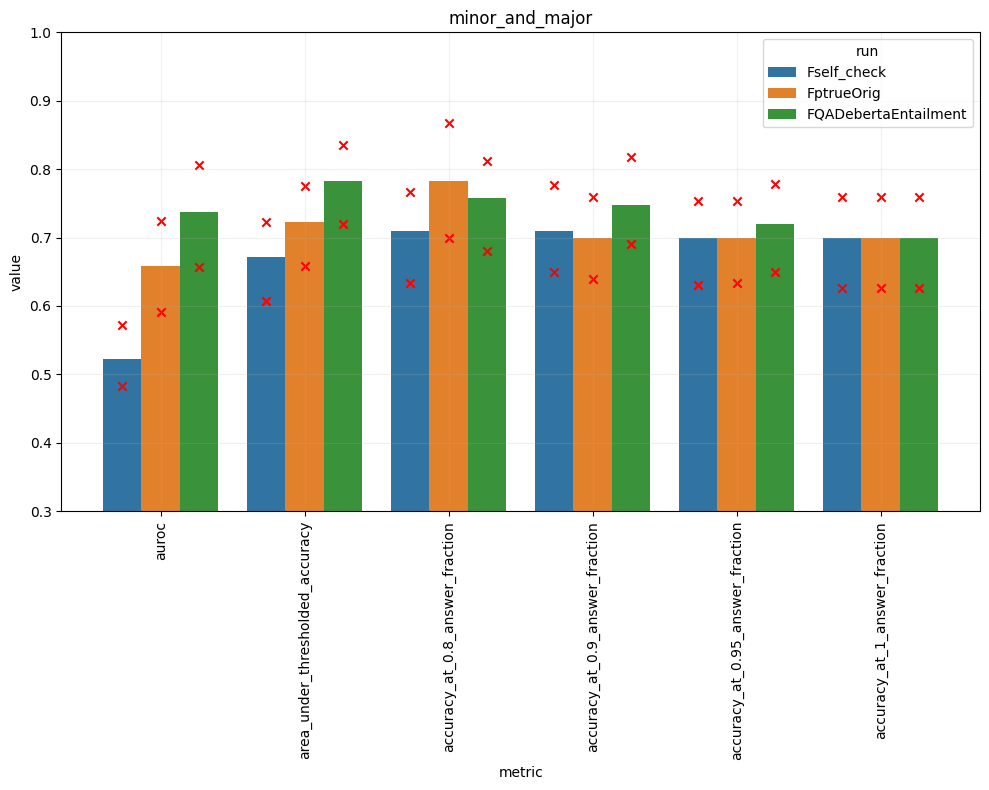

In [27]:
# final experiments
barplots(include=['Fself_check', 'FptrueOrig', 'FQADebertaEntailment'])

/tmp/ipykernel_1259822/2790621460.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_1259822/2790621460.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


<Figure size 640x480 with 0 Axes>

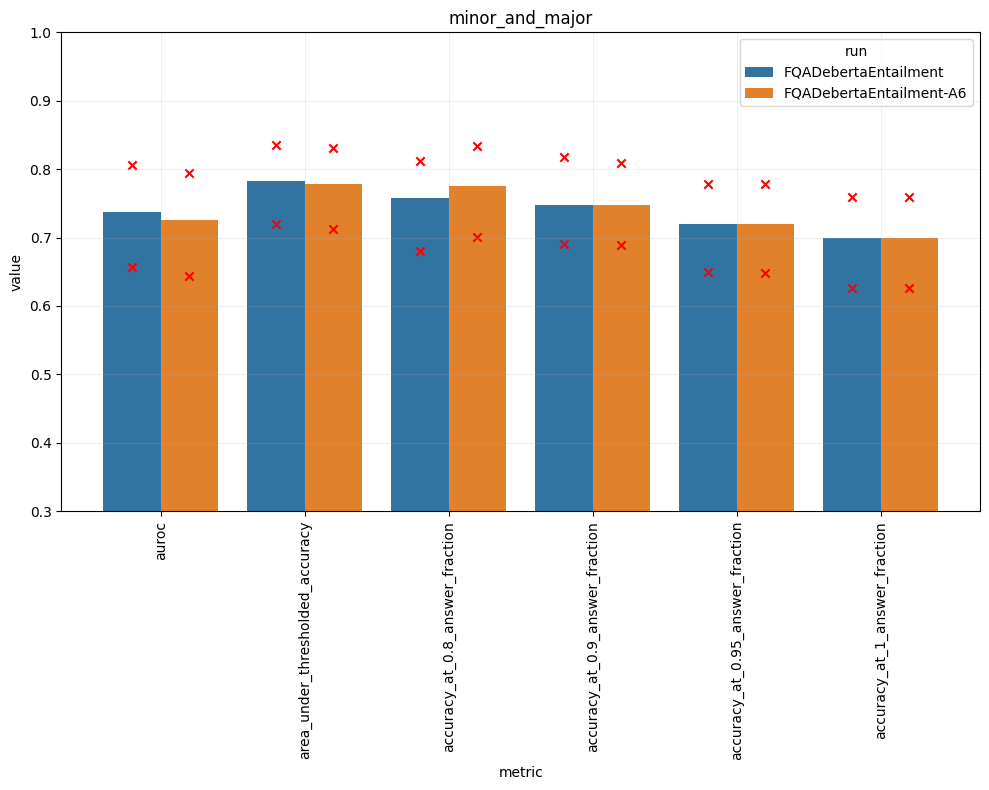

In [30]:
# ablation of different nubmer of regenerated answers
barplots(include=['FQADebertaEntailment', 'FQADebertaEntailment-A6'])

/tmp/ipykernel_1259822/2790621460.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_1259822/2790621460.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


<Figure size 640x480 with 0 Axes>

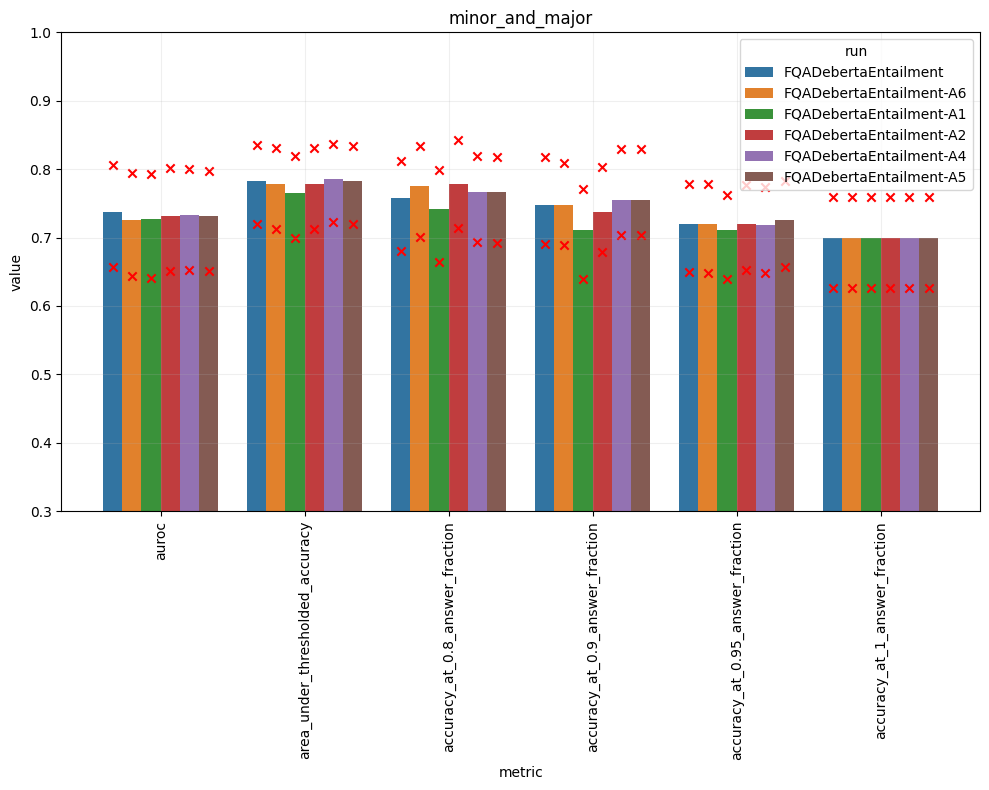

In [41]:
# UPDATE 25/11: filled in the gaps
# FQADebertaEntailment ist the default one with three regenerations per question!
barplots(include=['FQADebertaEntailment', 'FQADebertaEntailment-A6', 'FQADebertaEntailment-A5', 'FQADebertaEntailment-A4', 'FQADebertaEntailment-A2', 'FQADebertaEntailment-A1'])

/tmp/ipykernel_1259822/2790621460.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_1259822/2790621460.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


<Figure size 640x480 with 0 Axes>

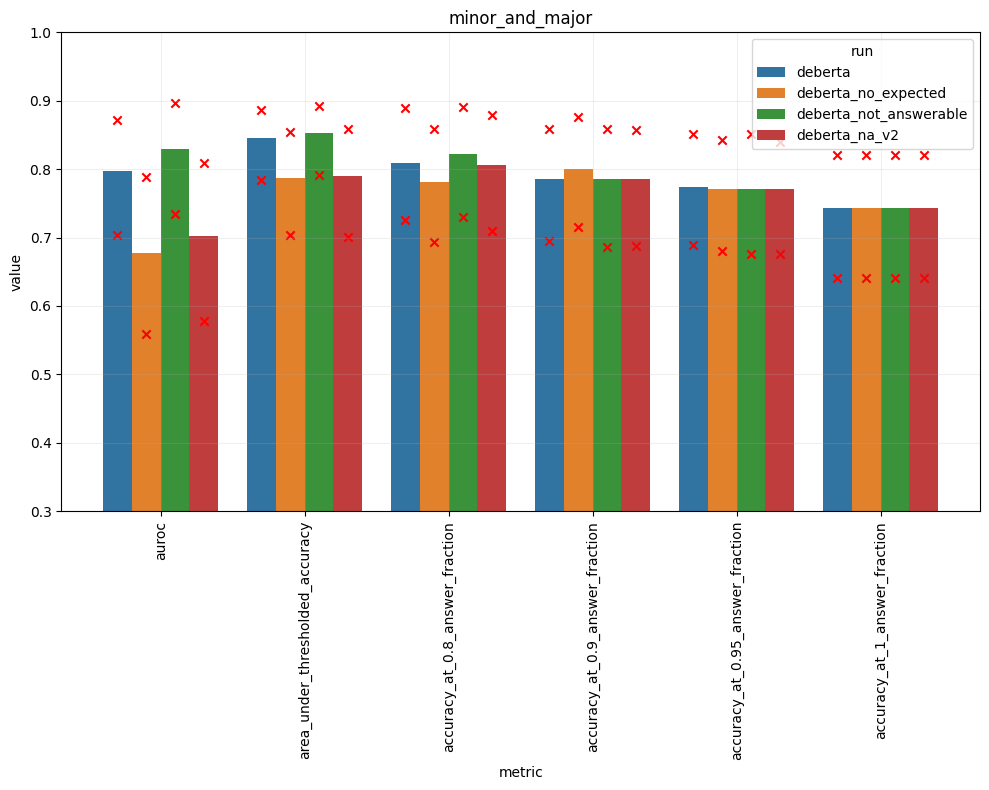

In [33]:
# some other deberta variants from preliminary investigation (dataset half the size)

# deberta_no_expected: deberta run where expected answer not used for clustering (comparison would be fairer if we had a new regen_answer)
# deberta_not_answerable: manually set uncertainty to maximum if 'not answerable', 'not provided', 'unclear', 'unknown' appears >= 2 times
# deberta_na_v2: is with not_answerable and improved question generation prompt

# NOTE: we end up using deberta_not_answerable!!
# NOTE: we are always using non-strict entailment here!!

barplots(
    include=['deberta', 'deberta_no_expected', 'deberta_not_answerable', 'deberta_na_v2']
)

/tmp/ipykernel_1259822/2790621460.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_1259822/2790621460.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


<Figure size 640x480 with 0 Axes>

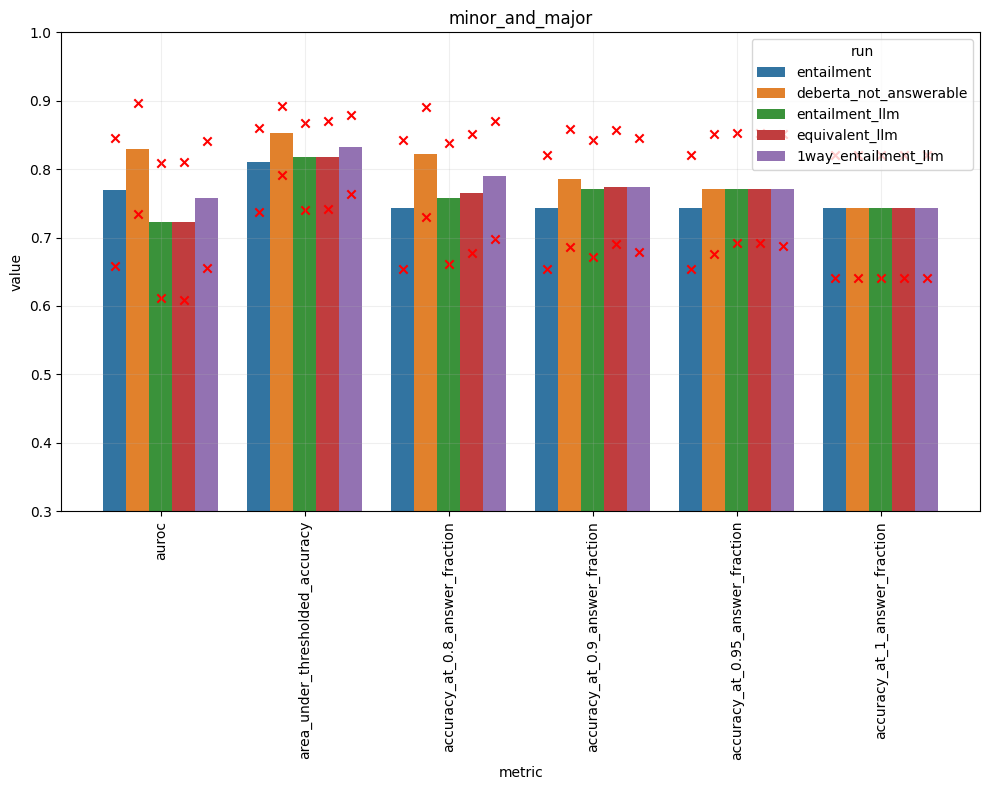

In [36]:
# some other variants from preliminary investigation (dataset half the size)


# LLM equivalence + clustering

# entailment: directly ask LLM if the generated answers are equivalent
# entailment_llm: check entailment with gpt-4
# equivalent_llm: check if answers are 'equivalent' with gpt-4 (simple change of phrasing)
# 1way_entailment_llm: ask closer to how we actually compute (non-strict) entailment: at least one entails the other!

barplots(
    include=['entailment', 'entailment_llm', 'equivalent_llm', '1way_entailment_llm', 'deberta_not_answerable']
)